# Onion Features in Feedforward Autoencoders

Csordás et al. (2024) discovered **onion representations** in capacity-bottlenecked GRUs: features encoded along the **same direction** but at **different radii** (concentric shells). This is a nonlinear encoding invisible to linear probes.

**Question:** Can feedforward autoencoders learn onion-like representations?

**Key theoretical requirement:** Encoder biases are necessary. Bias-free ReLU networks are positively homogeneous (`f(t*x) = t*f(x)`), making trajectories perfectly linear through the origin. With biases, `z(t*e_i)` can be nonlinear in `t`, enabling sigmoid-like trajectories that plateau at different radii (shells).

We use `n=8, m=2` (high compression, direct 2D visualization) with importance hierarchy and high sparsity.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from core import (
    Autoencoder, generate_sparse_data, get_feature_importance,
    train_autoencoder, run_experiment_multi_seed,
    measure_encoding_linearity, compute_feature_geometry, device
)

print(f"Device: {device}")

Device: cpu


## Section 2: Train Primary Model

Parameters chosen to encourage onion features:
- `n=8, m=2` — 4:1 compression, m=2 for direct visualization
- `l=3` — nonlinear capacity with biases
- `S=0.95` — high sparsity so features rarely co-activate (direction-sharing is safe)
- `importance_decay=0.5` — aggressive hierarchy (256:1 ratio between feature 0 and 7)
- `tied_weights=False` — required for l>1; encoder has biases

In [2]:
# Train primary model with 10 seeds
primary_result = run_experiment_multi_seed(
    n=8, m=2, l=3,
    n_seeds=10,
    S=0.95,
    n_steps=10000,
    importance_decay=0.5,
    tied_weights=False,
    verbose=True
)

model = primary_result['model']
model.eval()

print(f"\nFinal loss: {primary_result['final_loss']:.6f}")
print(f"Nonlinear gain: {primary_result['nonlinear_gain']:.4f}")
print(f"Linearity score: {primary_result['linearity_score']:.4f}")
print(f"Feature norms: {[f'{x:.3f}' for x in primary_result['feature_norms']]}")
print(f"Min pairwise angle: {primary_result['min_angle']:.1f}°")


Multi-seed experiment: n=8, m=2, l=3, S=0.95, n_seeds=10
Using importance weighting: I_i = 0.5^i


Seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Seeds:   0%|          | 0/10 [00:04<?, ?it/s, loss=0.0021, min_norm=0.08, min_angle=41°]

Seeds:  10%|█         | 1/10 [00:04<00:42,  4.69s/it, loss=0.0021, min_norm=0.08, min_angle=41°]

Seeds:  10%|█         | 1/10 [00:08<00:42,  4.69s/it, loss=0.0003, min_norm=0.09, min_angle=43°]

...

Seeds:  90%|█████████ | 9/10 [00:38<00:04,  4.13s/it, loss=0.0008, min_norm=0.17, min_angle=13°]

Seeds:  90%|█████████ | 9/10 [00:42<00:04,  4.13s/it, loss=0.0006, min_norm=0.13, min_angle=46°]

Seeds: 100%|██████████| 10/10 [00:42<00:00,  4.12s/it, loss=0.0006, min_norm=0.13, min_angle=46°]

Seeds: 100%|██████████| 10/10 [00:42<00:00,  4.25s/it, loss=0.0006, min_norm=0.13, min_angle=46°]


Best seed: 6, loss: 0.000128
Seeds tried: 10/10
Loss range across seeds: [0.000128, 0.003107]
Geometry: min_norm=0.059, min_angle=5.5°
Results: linearity=0.996, nonlinear_gain=0.124

Final loss: 0.000128
Nonlinear gain: 0.1236
Linearity score: 0.9962
Feature norms: ['1.581', '1.945', '1.446', '0.769', '0.293', '0.482', '0.059', '0.078']
Min pairwise angle: 5.5°


## Section 3: Feature Trajectory Analysis

Core visualization: sweep `x = t * e_i` for each feature and plot the resulting latent codes `z(t * e_i)`. Under onion encoding, trajectories for different features should follow the **same direction** but plateau at **different radii** ordered by importance.

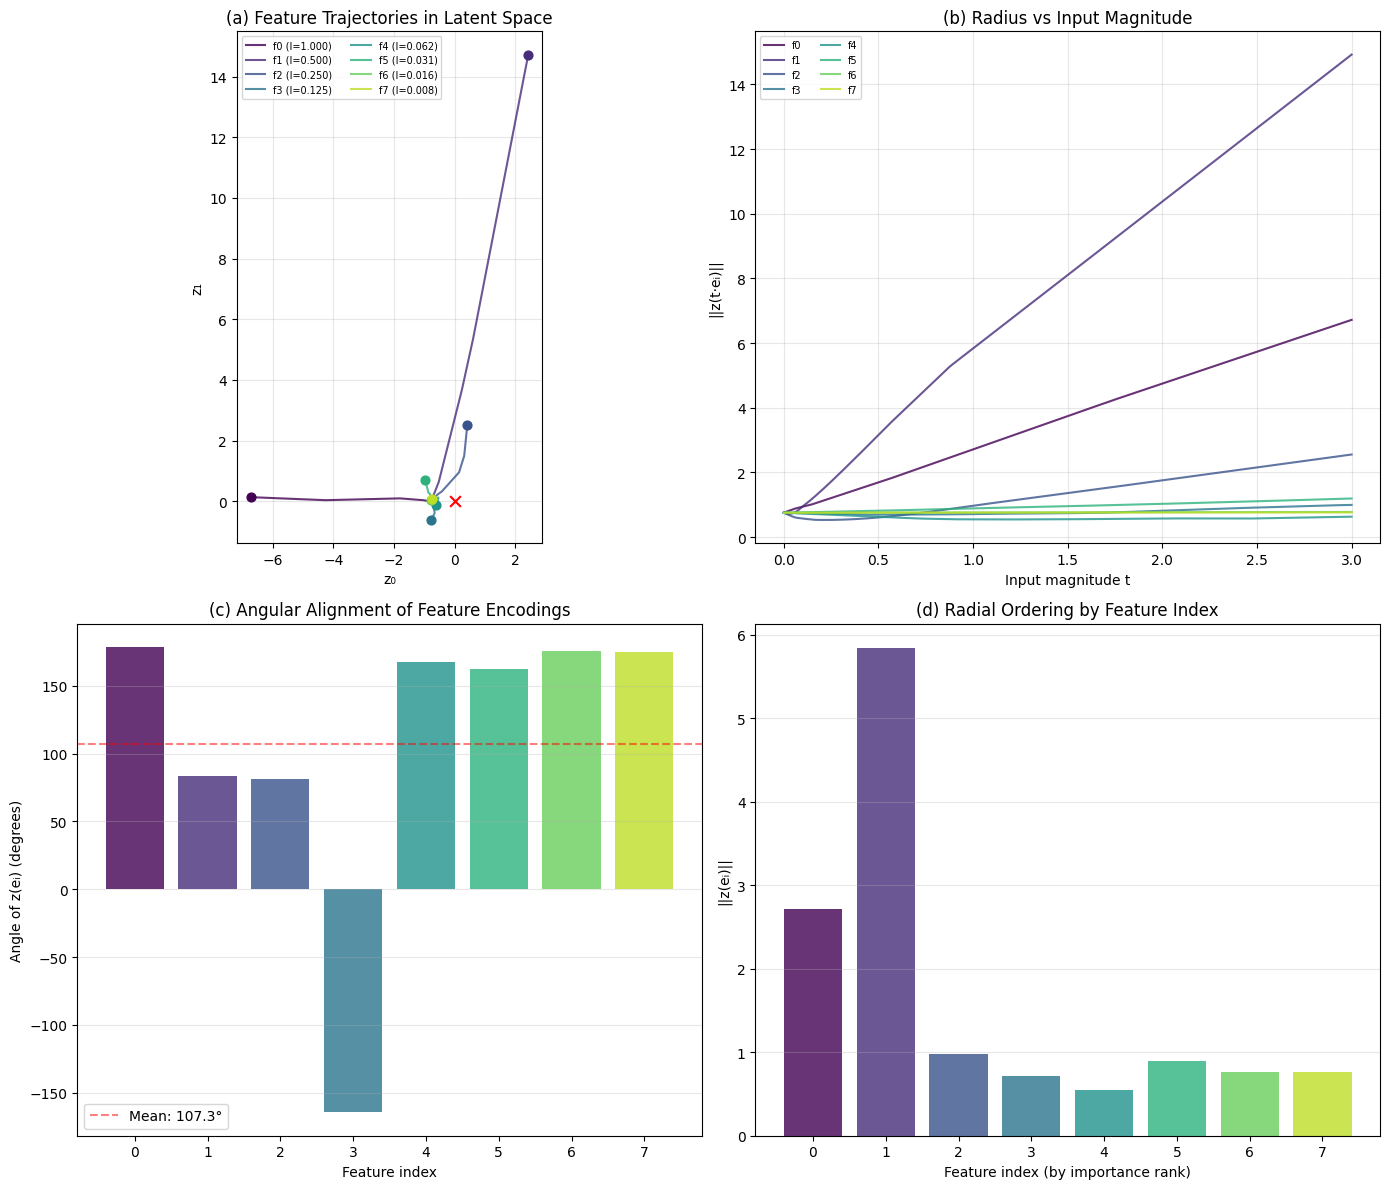

Pairwise cosine similarity of z(eᵢ) directions:
[[ 1.    -0.092 -0.124  0.956  0.982  0.961  0.999  0.998]
 [-0.092  1.     0.999 -0.381  0.098  0.186 -0.037 -0.032]
 [-0.124  0.999  1.    -0.411  0.065  0.154 -0.071 -0.065]
 [ 0.956 -0.381 -0.411  1.     0.883  0.838  0.938  0.936]
 [ 0.982  0.098  0.065  0.883  1.     0.996  0.991  0.992]
 [ 0.961  0.186  0.154  0.838  0.996  1.     0.975  0.976]
 [ 0.999 -0.037 -0.071  0.938  0.991  0.975  1.     1.   ]
 [ 0.998 -0.032 -0.065  0.936  0.992  0.976  1.     1.   ]]

Mean |cosine similarity|: 0.6119
Spearman(importance rank, radius): r=-0.6190, p=0.1017
  (Perfect onion: r=-1.0, higher importance → larger radius)


In [3]:
def compute_feature_trajectories(model, n_features=None, n_points=200, max_mag=3.0):
    """Compute latent trajectories z(t * e_i) for each feature."""
    if n_features is None:
        n_features = model.n
    t_vals = torch.linspace(0, max_mag, n_points, device=device)
    trajectories = []  # list of (n_points, m) arrays
    
    with torch.no_grad():
        for i in range(n_features):
            x = torch.zeros(n_points, model.n, device=device)
            x[:, i] = t_vals
            z = model.encode(x)
            trajectories.append(z.cpu().numpy())
    
    return t_vals.cpu().numpy(), trajectories


def plot_onion_trajectories(model, importance_decay=0.5, n_points=200, max_mag=3.0):
    """4-panel figure analyzing feature trajectories for onion structure."""
    n = model.n
    t_vals, trajectories = compute_feature_trajectories(model, n, n_points, max_mag)
    importance = get_feature_importance(n, importance_decay).cpu().numpy()
    
    # Compute unit-magnitude encodings z(e_i)
    with torch.no_grad():
        eye = torch.eye(n, device=device)
        z_unit = model.encode(eye).cpu().numpy()  # (n, m)
    
    radii = np.linalg.norm(z_unit, axis=1)
    directions = z_unit / (radii[:, None] + 1e-10)
    
    colors = cm.viridis(np.linspace(0, 0.9, n))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # (a) 2D trajectories in latent space
    ax = axes[0, 0]
    for i in range(n):
        traj = trajectories[i]
        ax.plot(traj[:, 0], traj[:, 1], color=colors[i], linewidth=1.5,
                label=f'f{i} (I={importance[i]:.3f})', alpha=0.8)
        # Mark endpoint
        ax.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], s=40, zorder=5)
    ax.scatter(0, 0, color='red', s=60, zorder=10, marker='x')
    ax.set_xlabel('z₀'); ax.set_ylabel('z₁')
    ax.set_title('(a) Feature Trajectories in Latent Space')
    ax.legend(fontsize=7, ncol=2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # (b) Radius vs input magnitude
    ax = axes[0, 1]
    for i in range(n):
        traj = trajectories[i]
        r = np.linalg.norm(traj, axis=1)
        ax.plot(t_vals, r, color=colors[i], linewidth=1.5,
                label=f'f{i}', alpha=0.8)
    ax.set_xlabel('Input magnitude t')
    ax.set_ylabel('||z(t·eᵢ)||')
    ax.set_title('(b) Radius vs Input Magnitude')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # (c) Angular alignment
    ax = axes[1, 0]
    angles_deg = np.arctan2(z_unit[:, 1], z_unit[:, 0]) * 180 / np.pi
    bars = ax.bar(range(n), angles_deg, color=colors, alpha=0.8)
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Angle of z(eᵢ) (degrees)')
    ax.set_title('(c) Angular Alignment of Feature Encodings')
    ax.set_xticks(range(n))
    ax.grid(True, alpha=0.3, axis='y')
    # Add reference line for mean angle
    mean_angle = np.mean(angles_deg)
    ax.axhline(mean_angle, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_angle:.1f}°')
    ax.legend()
    
    # (d) Radial ordering
    ax = axes[1, 1]
    bars = ax.bar(range(n), radii, color=colors, alpha=0.8)
    ax.set_xlabel('Feature index (by importance rank)')
    ax.set_ylabel('||z(eᵢ)||')
    ax.set_title('(d) Radial Ordering by Feature Index')
    ax.set_xticks(range(n))
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Quantitative metrics
    # Pairwise cosine similarity matrix
    cos_sim = directions @ directions.T
    print("Pairwise cosine similarity of z(eᵢ) directions:")
    print(np.array2string(cos_sim, precision=3, suppress_small=True))
    
    # Upper triangle mean absolute cosine similarity
    triu_idx = np.triu_indices(n, k=1)
    mean_abs_cos = np.mean(np.abs(cos_sim[triu_idx]))
    print(f"\nMean |cosine similarity|: {mean_abs_cos:.4f}")
    
    # Spearman correlation: importance rank vs radius
    rank_corr, rank_p = stats.spearmanr(range(n), radii)
    print(f"Spearman(importance rank, radius): r={rank_corr:.4f}, p={rank_p:.4f}")
    print(f"  (Perfect onion: r=-1.0, higher importance → larger radius)")
    
    return {
        'z_unit': z_unit, 'radii': radii, 'directions': directions,
        'cos_sim': cos_sim, 'mean_abs_cos': mean_abs_cos,
        'rank_corr': rank_corr, 'rank_p': rank_p,
        'trajectories': trajectories, 't_vals': t_vals
    }

traj_results = plot_onion_trajectories(model, importance_decay=0.5)

## Section 4: Decoder-Based Shell Visualization

Map out what the decoder does across the 2D latent space. If onion features are present, we should see concentric rings where different features dominate at different radii.

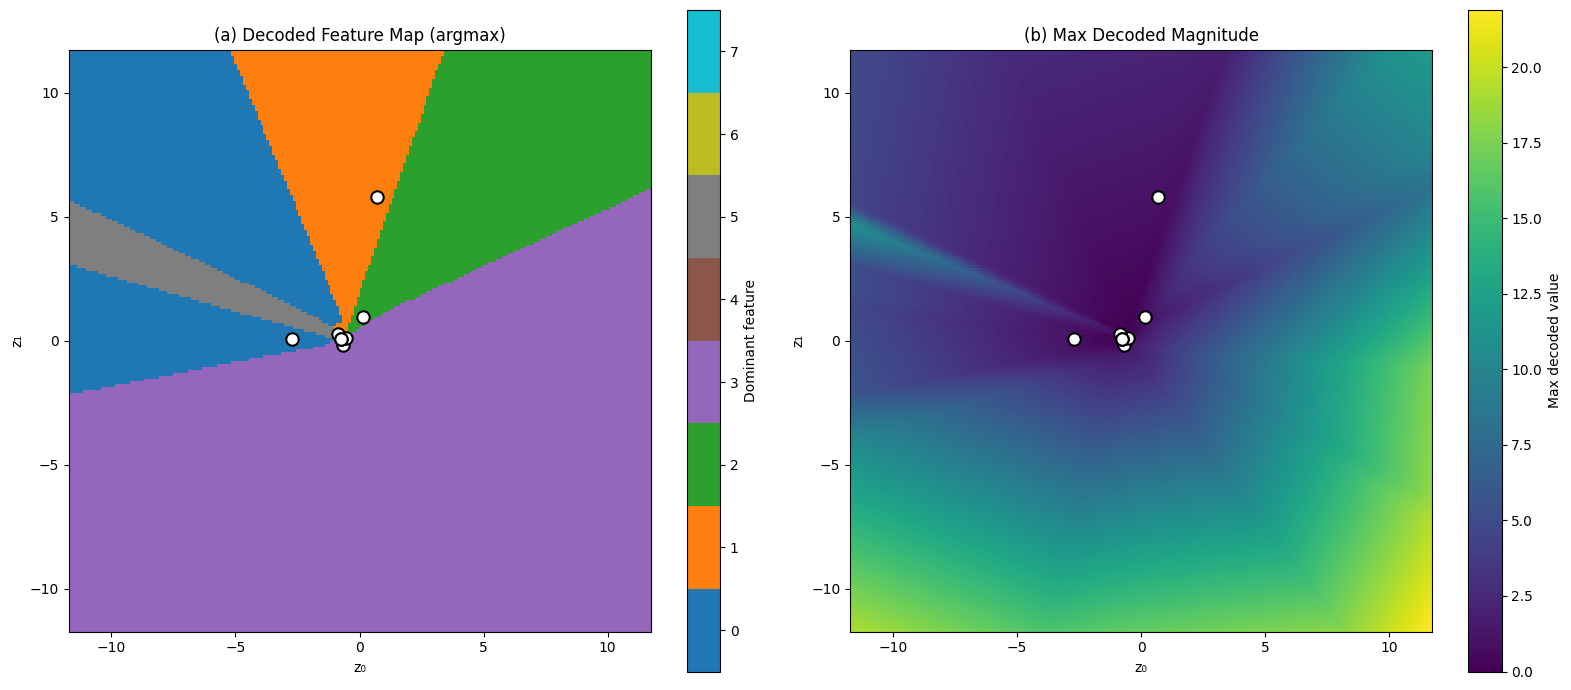

In [4]:
def plot_decoder_shells(model, grid_size=200, radius_scale=2.0, traj_results=None):
    """Visualize decoder behavior across 2D latent space."""
    # Create grid over latent space
    # Determine scale from feature encodings
    if traj_results is not None:
        max_r = np.max(traj_results['radii']) * radius_scale
    else:
        with torch.no_grad():
            eye = torch.eye(model.n, device=device)
            z_unit = model.encode(eye).cpu().numpy()
        max_r = np.max(np.linalg.norm(z_unit, axis=1)) * radius_scale
    
    z0 = np.linspace(-max_r, max_r, grid_size)
    z1 = np.linspace(-max_r, max_r, grid_size)
    Z0, Z1 = np.meshgrid(z0, z1)
    
    z_grid = torch.tensor(
        np.stack([Z0.ravel(), Z1.ravel()], axis=1),
        dtype=torch.float32, device=device
    )
    
    with torch.no_grad():
        x_decoded = model.decode(z_grid).cpu().numpy()  # (grid_size^2, n)
    
    argmax_feature = np.argmax(x_decoded, axis=1).reshape(grid_size, grid_size)
    max_magnitude = np.max(x_decoded, axis=1).reshape(grid_size, grid_size)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # (a) Argmax feature map
    ax = axes[0]
    cmap = cm.get_cmap('tab10', model.n)
    im = ax.pcolormesh(Z0, Z1, argmax_feature, cmap=cmap,
                       vmin=-0.5, vmax=model.n - 0.5, shading='auto')
    cbar = plt.colorbar(im, ax=ax, ticks=range(model.n))
    cbar.set_label('Dominant feature')
    
    # Overlay trajectory endpoints
    if traj_results is not None:
        z_unit = traj_results['z_unit']
        colors = cm.viridis(np.linspace(0, 0.9, model.n))
        for i in range(model.n):
            ax.scatter(z_unit[i, 0], z_unit[i, 1], color='white',
                      s=80, edgecolors='black', linewidths=1.5, zorder=5)
            ax.annotate(f'{i}', (z_unit[i, 0], z_unit[i, 1]),
                       fontsize=8, ha='center', va='center', fontweight='bold')
    
    ax.set_xlabel('z₀'); ax.set_ylabel('z₁')
    ax.set_title('(a) Decoded Feature Map (argmax)')
    ax.set_aspect('equal')
    
    # (b) Max decoded magnitude
    ax = axes[1]
    im = ax.pcolormesh(Z0, Z1, max_magnitude, cmap='viridis', shading='auto')
    plt.colorbar(im, ax=ax, label='Max decoded value')
    
    if traj_results is not None:
        z_unit = traj_results['z_unit']
        for i in range(model.n):
            ax.scatter(z_unit[i, 0], z_unit[i, 1], color='white',
                      s=80, edgecolors='black', linewidths=1.5, zorder=5)
            ax.annotate(f'{i}', (z_unit[i, 0], z_unit[i, 1]),
                       fontsize=8, ha='center', va='center', fontweight='bold')
    
    ax.set_xlabel('z₀'); ax.set_ylabel('z₁')
    ax.set_title('(b) Max Decoded Magnitude')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

plot_decoder_shells(model, traj_results=traj_results)

## Section 5: Multi-Feature Superposition

When two features are active simultaneously, where does the encoding land? Under onion encoding, the combined encoding should interpolate along the shared direction between shells.

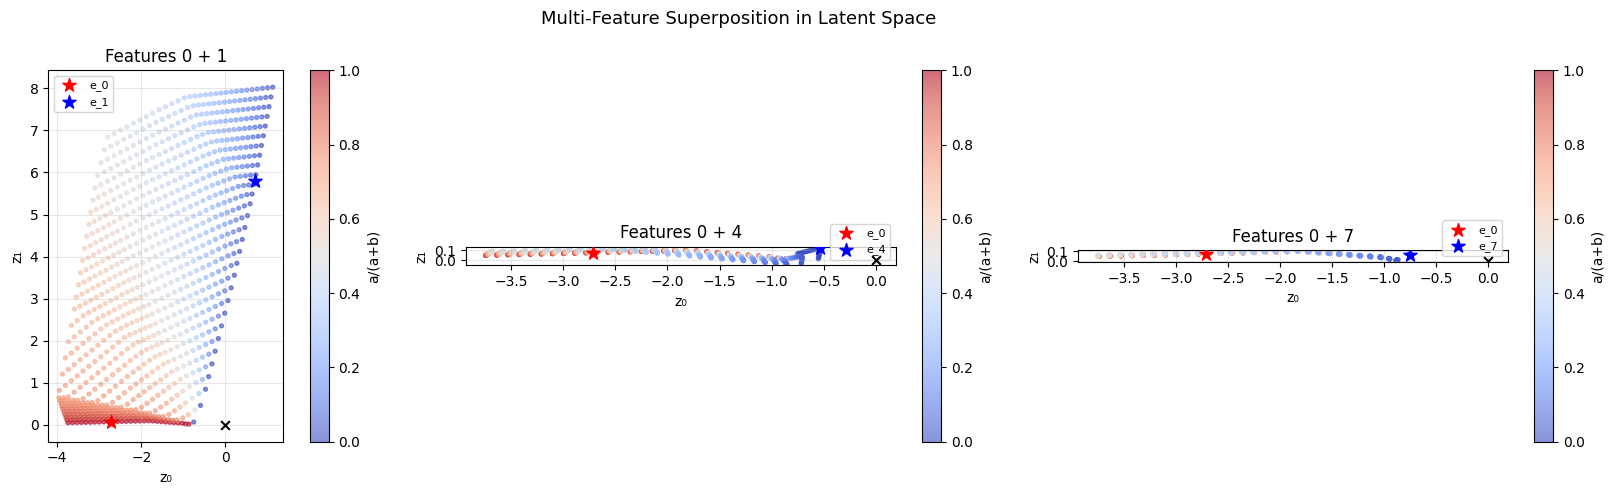

In [5]:
def plot_superposition_encoding(model, feature_pairs=None, grid_res=30, max_mag=1.5):
    """Plot latent encodings when two features are simultaneously active."""
    if feature_pairs is None:
        feature_pairs = [(0, 1), (0, 4), (0, 7)]
    
    n_pairs = len(feature_pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5))
    if n_pairs == 1:
        axes = [axes]
    
    a_vals = np.linspace(0, max_mag, grid_res)
    b_vals = np.linspace(0, max_mag, grid_res)
    A, B = np.meshgrid(a_vals, b_vals)
    
    for idx, (fi, fj) in enumerate(feature_pairs):
        ax = axes[idx]
        
        # Build inputs: x = a*e_i + b*e_j
        n_pts = grid_res * grid_res
        x = torch.zeros(n_pts, model.n, device=device)
        x[:, fi] = torch.tensor(A.ravel(), dtype=torch.float32, device=device)
        x[:, fj] = torch.tensor(B.ravel(), dtype=torch.float32, device=device)
        
        with torch.no_grad():
            z = model.encode(x).cpu().numpy()
        
        # Color by ratio a/(a+b) to show mixing
        ratio = A.ravel() / (A.ravel() + B.ravel() + 1e-10)
        
        sc = ax.scatter(z[:, 0], z[:, 1], c=ratio, cmap='coolwarm',
                       s=8, alpha=0.6, vmin=0, vmax=1)
        plt.colorbar(sc, ax=ax, label=f'a/(a+b)')
        
        # Mark pure feature directions
        with torch.no_grad():
            e_i = torch.zeros(1, model.n, device=device)
            e_i[0, fi] = 1.0
            e_j = torch.zeros(1, model.n, device=device)
            e_j[0, fj] = 1.0
            z_i = model.encode(e_i).cpu().numpy()[0]
            z_j = model.encode(e_j).cpu().numpy()[0]
        
        ax.scatter(*z_i, color='red', s=100, marker='*', zorder=10, label=f'e_{fi}')
        ax.scatter(*z_j, color='blue', s=100, marker='*', zorder=10, label=f'e_{fj}')
        ax.scatter(0, 0, color='black', s=40, marker='x', zorder=10)
        
        ax.set_xlabel('z₀'); ax.set_ylabel('z₁')
        ax.set_title(f'Features {fi} + {fj}')
        ax.legend(fontsize=8)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Multi-Feature Superposition in Latent Space', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_superposition_encoding(model)

## Section 6: Quantitative Onion Metrics

Define metrics that capture the degree of "onion-ness":
1. **Angular clustering**: Mean |cosine similarity| between feature encoding directions (1.0 = perfect onion)
2. **Radial-importance correlation**: Spearman(importance rank, ||z(eᵢ)||) (-1.0 = perfect ordering)
3. **Shell separation ratio**: Ratio of adjacent shell radii
4. **Nonlinear gain**: From existing measurement

In [6]:
def compute_onion_metrics(model, importance_decay=0.5, S=0.95):
    """Compute quantitative metrics for onion-ness of the encoding."""
    n = model.n
    model.eval()
    
    # Encode unit basis vectors
    with torch.no_grad():
        eye = torch.eye(n, device=device)
        z_unit = model.encode(eye).cpu().numpy()  # (n, m)
    
    radii = np.linalg.norm(z_unit, axis=1)
    directions = z_unit / (radii[:, None] + 1e-10)
    
    # 1. Angular clustering: mean |cosine similarity|
    cos_sim = directions @ directions.T
    triu_idx = np.triu_indices(n, k=1)
    angular_clustering = np.mean(np.abs(cos_sim[triu_idx]))
    
    # 2. Radial-importance correlation
    rank_corr, rank_p = stats.spearmanr(range(n), radii)
    
    # 3. Shell separation: ratio of consecutive radii (sorted descending)
    sorted_radii = np.sort(radii)[::-1]
    shell_ratios = sorted_radii[:-1] / (sorted_radii[1:] + 1e-10)
    mean_shell_ratio = np.mean(shell_ratios)
    
    # 4. Nonlinear gain
    linearity = measure_encoding_linearity(model, S=S)
    
    # 5. Encoder bias magnitude (relative to typical activations)
    bias_magnitudes = []
    for name, param in model.encoder.named_parameters():
        if 'bias' in name:
            bias_magnitudes.append(param.detach().cpu().numpy())
    
    mean_bias_norm = np.mean([np.linalg.norm(b) for b in bias_magnitudes]) if bias_magnitudes else 0.0
    
    metrics = {
        'angular_clustering': angular_clustering,
        'radial_importance_corr': rank_corr,
        'radial_importance_p': rank_p,
        'mean_shell_ratio': mean_shell_ratio,
        'nonlinear_gain': linearity['nonlinear_gain'],
        'linearity_score': linearity['linearity_score'],
        'mean_bias_norm': mean_bias_norm,
        'radii': radii,
        'directions': directions,
    }
    
    return metrics

# Compute for primary model
primary_metrics = compute_onion_metrics(model, importance_decay=0.5)

print("=== Onion Metrics (Primary Model) ===")
print(f"Angular clustering:        {primary_metrics['angular_clustering']:.4f}  (1.0 = perfect onion)")
print(f"Radial-importance corr:    {primary_metrics['radial_importance_corr']:.4f}  (-1.0 = perfect ordering)")
print(f"  p-value:                 {primary_metrics['radial_importance_p']:.4f}")
print(f"Mean shell ratio:          {primary_metrics['mean_shell_ratio']:.4f}")
print(f"Nonlinear gain:            {primary_metrics['nonlinear_gain']:.4f}")
print(f"Linearity score:           {primary_metrics['linearity_score']:.4f}")
print(f"Mean encoder bias norm:    {primary_metrics['mean_bias_norm']:.4f}")
print(f"Radii by feature:          {[f'{r:.3f}' for r in primary_metrics['radii']]}")

=== Onion Metrics (Primary Model) ===
Angular clustering:        0.6119  (1.0 = perfect onion)
Radial-importance corr:    -0.6190  (-1.0 = perfect ordering)
  p-value:                 0.1017
Mean shell ratio:          1.5096
Nonlinear gain:            0.1158
Linearity score:           0.9926
Mean encoder bias norm:    0.5854
Radii by feature:          ['2.713', '5.836', '0.973', '0.712', '0.549', '0.889', '0.763', '0.758']


## Section 7: When Do Onion Features Emerge?

Four sweeps over key hyperparameters, 5 seeds each. We plot individual runs + means per experimental standards.

In [7]:
def run_onion_sweep(sweep_name, sweep_var, sweep_values, fixed_params, n_seeds=5, n_steps=15000):
    """Run a parameter sweep computing onion metrics at each point.
    
    Returns list of dicts with sweep_val, seed, and all onion metrics.
    """
    results = []
    
    for val in tqdm(sweep_values, desc=f"{sweep_name} sweep"):
        for seed in range(n_seeds):
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            params = dict(fixed_params)
            params[sweep_var] = val
            
            # Extract core.py params
            n = params.pop('n', 8)
            m = params.pop('m', 2)
            l = params.pop('l', 3)
            S = params.pop('S', 0.95)
            importance_decay = params.pop('importance_decay', 0.5)
            tied = params.pop('tied_weights', False)
            
            model_i = Autoencoder(n, m, l, tied_weights=tied).to(device)
            importance = get_feature_importance(n, importance_decay, device=device)
            
            train_autoencoder(
                model_i, n_steps=n_steps, S=S,
                importance=importance, verbose=False
            )
            
            metrics = compute_onion_metrics(model_i, importance_decay=importance_decay, S=S)
            
            results.append({
                'sweep_val': val,
                'seed': seed,
                **{k: v for k, v in metrics.items() if not isinstance(v, np.ndarray)}
            })
    
    return results


def plot_sweep_results(results, sweep_name, sweep_var_label, sweep_values):
    """Plot onion metrics vs sweep variable. Shows individual runs + means."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metric_names = [
        ('angular_clustering', 'Angular Clustering', '1.0 = perfect onion'),
        ('radial_importance_corr', 'Radial-Importance Corr', '-1.0 = perfect ordering'),
        ('nonlinear_gain', 'Nonlinear Gain', 'Higher = more nonlinear'),
    ]
    
    for ax, (metric_key, metric_label, note) in zip(axes, metric_names):
        # Individual runs
        for r in results:
            ax.scatter(r['sweep_val'], r[metric_key], color='steelblue',
                      alpha=0.3, s=20, zorder=3)
        
        # Means
        for val in sweep_values:
            vals = [r[metric_key] for r in results if r['sweep_val'] == val]
            mean_val = np.mean(vals)
            ax.scatter(val, mean_val, color='red', s=80, zorder=5, marker='D')
        
        # Connect means
        means = [np.mean([r[metric_key] for r in results if r['sweep_val'] == v])
                 for v in sweep_values]
        ax.plot(sweep_values, means, color='red', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel(sweep_var_label)
        ax.set_ylabel(metric_label)
        ax.set_title(f'{metric_label}\n({note})')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{sweep_name} Sweep', fontsize=14)
    plt.tight_layout()
    plt.show()

Compression sweep:   0%|          | 0/6 [00:00<?, ?it/s]

Compression sweep:  17%|█▋        | 1/6 [00:15<01:16, 15.33s/it]

Compression sweep:  33%|███▎      | 2/6 [00:30<01:01, 15.43s/it]

Compression sweep:  50%|█████     | 3/6 [00:46<00:47, 15.74s/it]

Compression sweep:  67%|██████▋   | 4/6 [01:05<00:33, 16.85s/it]

Compression sweep:  83%|████████▎ | 5/6 [01:24<00:17, 17.72s/it]

Compression sweep: 100%|██████████| 6/6 [01:45<00:00, 18.87s/it]

Compression sweep: 100%|██████████| 6/6 [01:45<00:00, 17.64s/it]

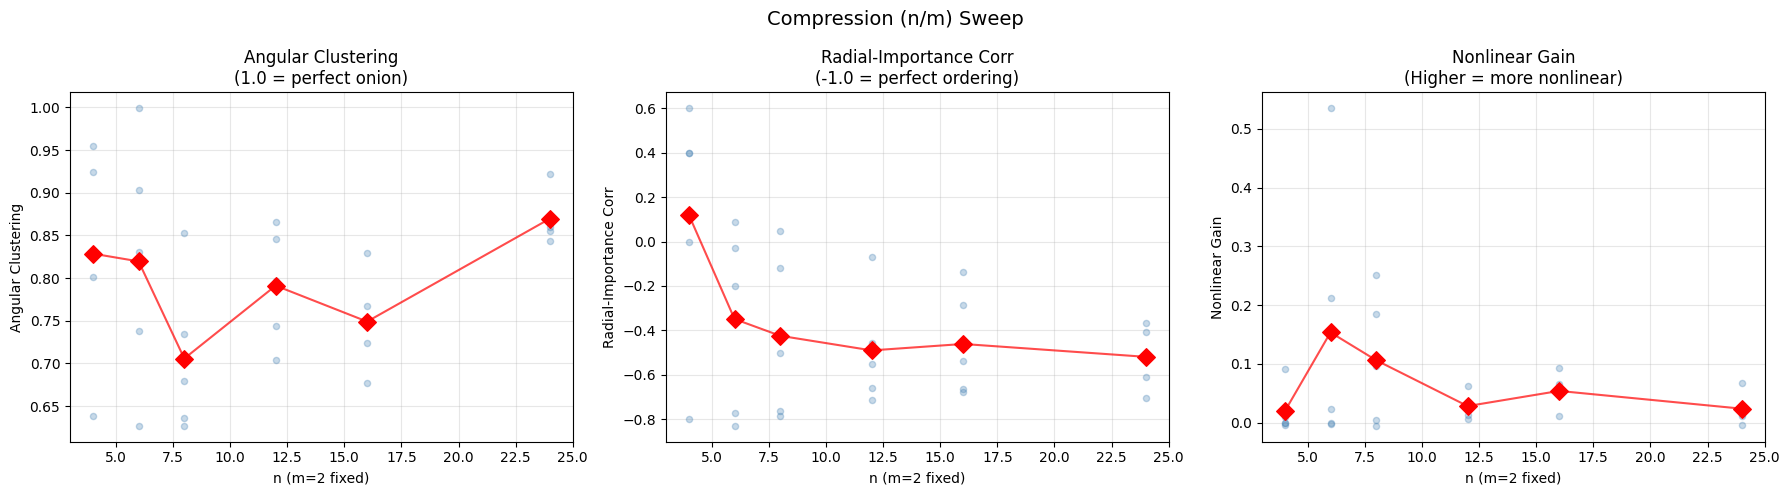

In [8]:
# Sweep 1: Compression (varying n with m=2 fixed)
n_values = [4, 6, 8, 12, 16, 24]
compression_results = run_onion_sweep(
    'Compression', 'n', n_values,
    fixed_params={'m': 2, 'l': 3, 'importance_decay': 0.5, 'S': 0.95, 'tied_weights': False},
    n_steps=8000
)
plot_sweep_results(compression_results, 'Compression (n/m)', 'n (m=2 fixed)', n_values)

Importance Decay sweep:   0%|          | 0/4 [00:00<?, ?it/s]

Importance Decay sweep:  25%|██▌       | 1/4 [00:15<00:46, 15.56s/it]

Importance Decay sweep:  50%|█████     | 2/4 [00:31<00:31, 15.97s/it]

Importance Decay sweep:  75%|███████▌  | 3/4 [00:48<00:16, 16.17s/it]

Importance Decay sweep: 100%|██████████| 4/4 [01:04<00:00, 16.31s/it]

Importance Decay sweep: 100%|██████████| 4/4 [01:04<00:00, 16.18s/it]

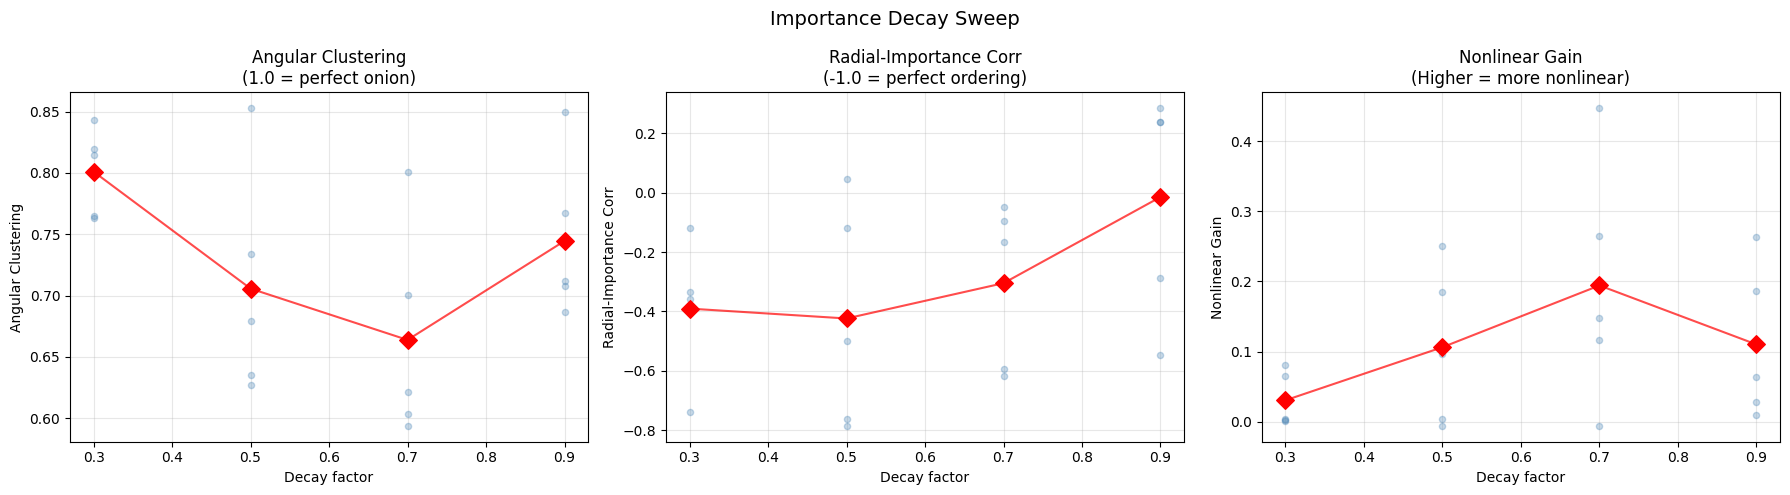

In [9]:
# Sweep 2: Importance decay
decay_values = [0.9, 0.7, 0.5, 0.3]
decay_results = run_onion_sweep(
    'Importance Decay', 'importance_decay', decay_values,
    fixed_params={'n': 8, 'm': 2, 'l': 3, 'S': 0.95, 'tied_weights': False},
    n_steps=8000
)
plot_sweep_results(decay_results, 'Importance Decay', 'Decay factor', decay_values)

Depth sweep:   0%|          | 0/5 [00:00<?, ?it/s]

Depth sweep:  20%|██        | 1/5 [00:07<00:30,  7.66s/it]

Depth sweep:  40%|████      | 2/5 [00:19<00:30, 10.26s/it]

Depth sweep:  60%|██████    | 3/5 [00:35<00:25, 12.74s/it]

Depth sweep:  80%|████████  | 4/5 [00:56<00:15, 15.87s/it]

Depth sweep: 100%|██████████| 5/5 [01:26<00:00, 21.07s/it]

Depth sweep: 100%|██████████| 5/5 [01:26<00:00, 17.28s/it]

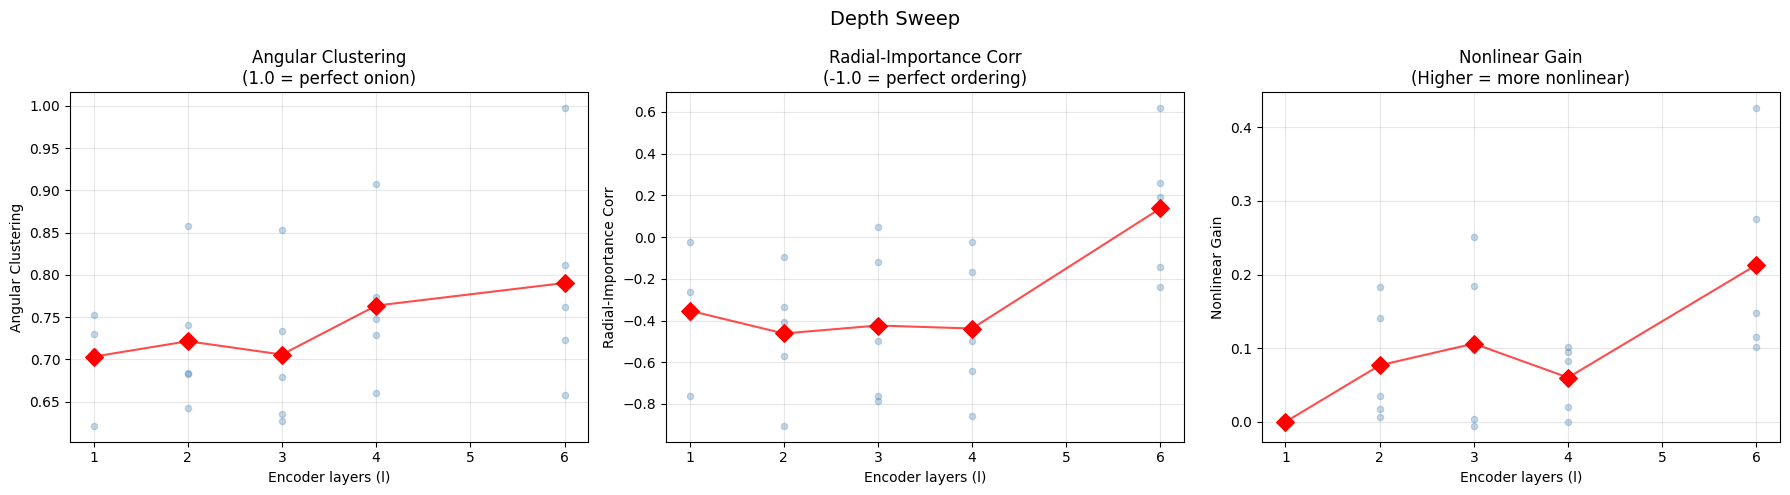

In [10]:
# Sweep 3: Depth
l_values = [1, 2, 3, 4, 6]
depth_results = run_onion_sweep(
    'Depth', 'l', l_values,
    fixed_params={'n': 8, 'm': 2, 'importance_decay': 0.5, 'S': 0.95, 'tied_weights': False},
    n_steps=8000
)
plot_sweep_results(depth_results, 'Depth', 'Encoder layers (l)', l_values)

Sparsity sweep:   0%|          | 0/5 [00:00<?, ?it/s]

Sparsity sweep:  20%|██        | 1/5 [00:16<01:05, 16.26s/it]

Sparsity sweep:  40%|████      | 2/5 [00:34<00:51, 17.19s/it]

Sparsity sweep:  60%|██████    | 3/5 [00:52<00:35, 17.56s/it]

Sparsity sweep:  80%|████████  | 4/5 [01:08<00:17, 17.01s/it]

Sparsity sweep: 100%|██████████| 5/5 [01:25<00:00, 16.95s/it]

Sparsity sweep: 100%|██████████| 5/5 [01:25<00:00, 17.02s/it]

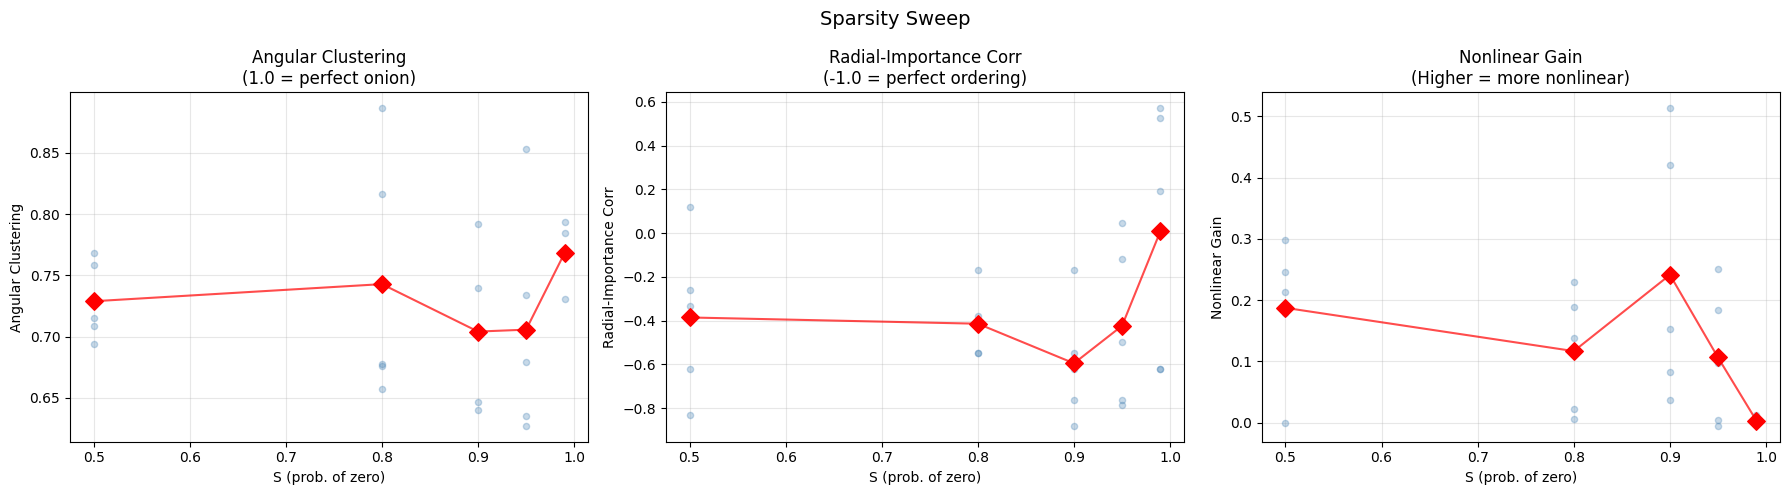

In [11]:
# Sweep 4: Sparsity
S_values = [0.5, 0.8, 0.9, 0.95, 0.99]
sparsity_results = run_onion_sweep(
    'Sparsity', 'S', S_values,
    fixed_params={'n': 8, 'm': 2, 'l': 3, 'importance_decay': 0.5, 'tied_weights': False},
    n_steps=8000
)
plot_sweep_results(sparsity_results, 'Sparsity', 'S (prob. of zero)', S_values)

## Section 8: Connection to Nonlinear Gain Framework

How does onion emergence relate to our existing phase diagram? We compare angular clustering with nonlinear gain across all sweep configurations, and inspect encoder biases.

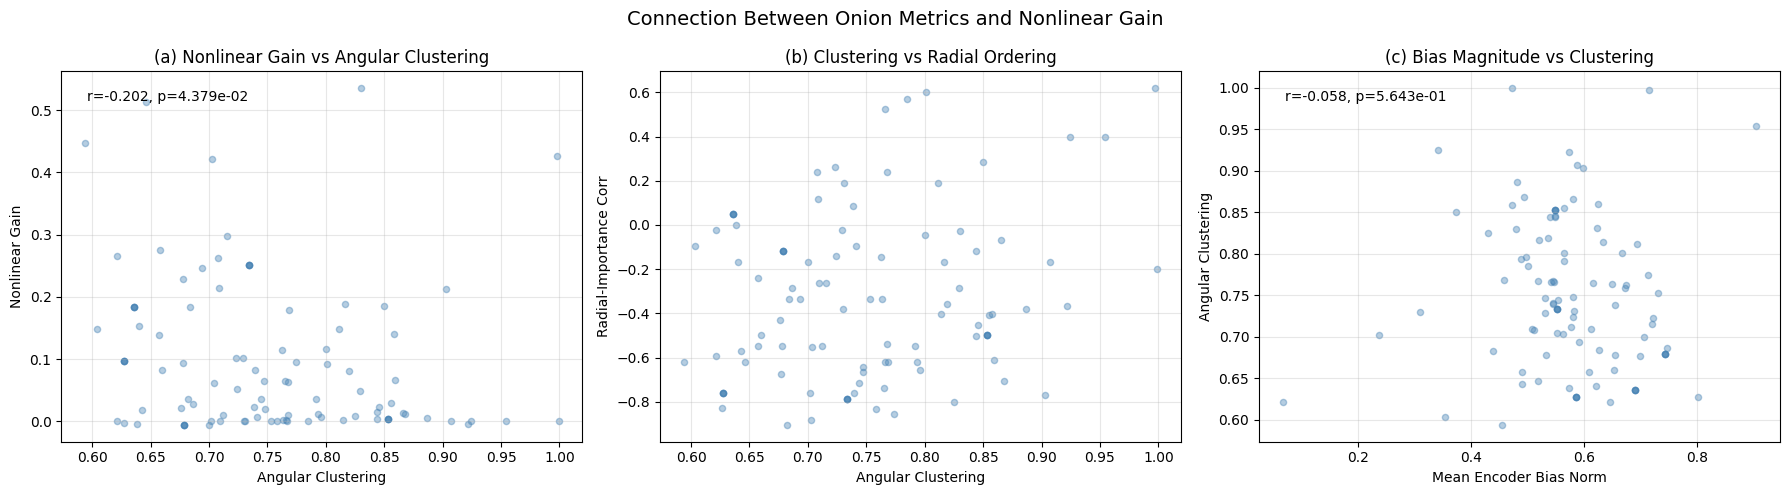


Across all 100 sweep configs:
  Angular clustering: mean=0.751, std=0.091
  Nonlinear gain:     mean=0.097, std=0.121
  Bias norm:          mean=0.575, std=0.116


In [12]:
# Combine all sweep results
all_sweep_results = (
    compression_results + decay_results + depth_results + sparsity_results
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Nonlinear gain vs angular clustering
ax = axes[0]
ng = [r['nonlinear_gain'] for r in all_sweep_results]
ac = [r['angular_clustering'] for r in all_sweep_results]
ax.scatter(ac, ng, alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Angular Clustering')
ax.set_ylabel('Nonlinear Gain')
ax.set_title('(a) Nonlinear Gain vs Angular Clustering')
ax.grid(True, alpha=0.3)

# Correlation
r_corr, p_corr = stats.pearsonr(ac, ng)
ax.text(0.05, 0.95, f'r={r_corr:.3f}, p={p_corr:.3e}',
        transform=ax.transAxes, fontsize=10, va='top')

# (b) Angular clustering vs radial-importance correlation
ax = axes[1]
ric = [r['radial_importance_corr'] for r in all_sweep_results]
ax.scatter(ac, ric, alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Angular Clustering')
ax.set_ylabel('Radial-Importance Corr')
ax.set_title('(b) Clustering vs Radial Ordering')
ax.grid(True, alpha=0.3)

# (c) Encoder bias magnitude vs angular clustering
ax = axes[2]
bn = [r['mean_bias_norm'] for r in all_sweep_results]
ax.scatter(bn, ac, alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Mean Encoder Bias Norm')
ax.set_ylabel('Angular Clustering')
ax.set_title('(c) Bias Magnitude vs Clustering')
ax.grid(True, alpha=0.3)

r_bias, p_bias = stats.pearsonr(bn, ac)
ax.text(0.05, 0.95, f'r={r_bias:.3f}, p={p_bias:.3e}',
        transform=ax.transAxes, fontsize=10, va='top')

plt.suptitle('Connection Between Onion Metrics and Nonlinear Gain', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nAcross all {len(all_sweep_results)} sweep configs:")
print(f"  Angular clustering: mean={np.mean(ac):.3f}, std={np.std(ac):.3f}")
print(f"  Nonlinear gain:     mean={np.mean(ng):.3f}, std={np.std(ng):.3f}")
print(f"  Bias norm:          mean={np.mean(bn):.3f}, std={np.std(bn):.3f}")

In [13]:
# Summary interpretation
print("=== Summary ===")
print(f"\nPrimary model (n=8, m=2, l=3, decay=0.5, S=0.95):")
print(f"  Angular clustering: {primary_metrics['angular_clustering']:.4f}")
print(f"  Radial-importance correlation: {primary_metrics['radial_importance_corr']:.4f}")
print(f"  Nonlinear gain: {primary_metrics['nonlinear_gain']:.4f}")
print(f"  Mean bias norm: {primary_metrics['mean_bias_norm']:.4f}")

if primary_metrics['angular_clustering'] > 0.8:
    print("\n→ High angular clustering detected: features share directions (onion-like)")
elif primary_metrics['angular_clustering'] > 0.5:
    print("\n→ Moderate angular clustering: partial direction sharing")
else:
    print("\n→ Low angular clustering: features use distinct directions (not onion)")

if primary_metrics['radial_importance_corr'] < -0.5:
    print("→ Radial ordering matches importance hierarchy")
else:
    print("→ Radial ordering does NOT match importance hierarchy")

if primary_metrics['nonlinear_gain'] > 0.05:
    print("→ Significant nonlinear gain: encoder uses nonlinear capacity")
else:
    print("→ Low nonlinear gain: encoding is approximately linear")

=== Summary ===

Primary model (n=8, m=2, l=3, decay=0.5, S=0.95):
  Angular clustering: 0.6119
  Radial-importance correlation: -0.6190
  Nonlinear gain: 0.1158
  Mean bias norm: 0.5854

→ Moderate angular clustering: partial direction sharing
→ Radial ordering matches importance hierarchy
→ Significant nonlinear gain: encoder uses nonlinear capacity
